# National secondary exams 2024: who does well, and does it match 2005/06?

The [student-performance project](../../projeto_student_performance) analysed **649 students from two schools in 2005/06**. Its main findings were:
- **past class failures** were the strongest predictor of a low final grade;
- **girls did better in Portuguese, boys in Maths**;
- one school (**Gabriel Pereira**, Évora) outperformed the other (**Mouzinho da Silveira**, Portalegre).

This notebook checks those findings against the **2024 national exam results (ENES 2024)**: every exam sat in Portugal that year, about 312,000 records.

**Data:** Júri Nacional de Exames / DGE, *ENES 2024* (press database). Run `python src/download_data.py` and then `python src/build_dataset.py` first.

**Outline**
1. Load the data and define the population
2. Who sits national exams in 2024? (an important caveat)
3. Results by subject
4. Gender gaps
5. Age, a proxy for past retention
6. Internal grades vs exam scores
7. Then and now

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
import style
style.apply()

FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG / f"{name}.png", dpi=120)

exams = pd.read_parquet(ROOT / "data" / "processed" / "exams_2024.parquet")
print(f"{len(exams):,} exam records")
exams.head()

311,909 exam records


,school_code,school_dgeec,school_name,sector,district,municipality,municipality_code,nuts3,phase,exam_code,...,age,internal_grade,exam_score,exam_score_20,final_grade,for_approval,for_improvement,for_admission,internal,enrolment_status
0,0002,1511640,Escola Básica e Secundária de Michel Giacomett...,Public,Setúbal,Sesimbra,1511,170,1,639,...,18,NaN,140,14.0,NaN,False,False,True,False,None
1,0002,1511640,Escola Básica e Secundária de Michel Giacomett...,Public,Setúbal,Sesimbra,1511,170,1,639,...,17,12.0,41,4.1,NaN,False,False,True,False,AP
2,0002,1511640,Escola Básica e Secundária de Michel Giacomett...,Public,Setúbal,Sesimbra,1511,170,1,639,...,17,15.0,100,10.0,NaN,False,False,True,False,AP
3,0002,1511640,Escola Básica e Secundária de Michel Giacomett...,Public,Setúbal,Sesimbra,1511,170,1,639,...,19,NaN,112,11.2,NaN,False,False,True,False,None
4,0002,1511640,Escola Básica e Secundária de Michel Giacomett...,Public,Setúbal,Sesimbra,1511,170,1,639,...,17,12.0,62,6.2,NaN,False,False,True,False,AP


## 1. Defining the population

One row is one exam sat by one student. Some records need filtering so that we compare like with like:
- **Phase 1 only.** Phase 2 is mostly retakes and improvement attempts.
- **No grade-improvement attempts** (`for_improvement`). These students already passed the subject and are trying to raise their grade.
- **Students with an internal grade** (`internal_grade`) for the subject. This keeps students who took the subject at school that year and excludes self-study candidates.

Exams are scored from 0 to 200. Internal grades go from 0 to 20, so we also use `exam_score_20` (score ÷ 10) to compare the two.

In [2]:
steps = [("All records", exams)]
p = exams[exams["phase"] == 1];          steps.append(("Phase 1", p))
p = p[~p["for_improvement"]];            steps.append(("… not an improvement attempt", p))
p = p[p["internal_grade"].notna()];      steps.append(("… with an internal grade", p))
pop = p.copy()

pd.DataFrame({"step": [s for s, _ in steps], "records": [len(d) for _, d in steps],
              "students' schools": [d["school_code"].nunique() for _, d in steps]})

,step,records,students' schools
0,All records,311909,652
1,Phase 1,235087,652
2,… not an improvement attempt,199985,652
3,… with an internal grade,150844,641


## 2. Who sits national exams in 2024?

In [3]:
print(f"Exams taken for higher-education admission: {exams['for_admission'].mean():.1%}")
print(f"Exams that also count towards passing the subject: {exams['for_approval'].mean():.1%}")
print()
print("Course type of exam takers in our population:")
print(pop["course"].value_counts().head(5).to_string())

Exams taken for higher-education admission: 97.8%
Exams that also count towards passing the subject: 32.6%

Course type of exam takers in our population:
course
Ciências e Tecnologias      73549
Línguas e Humanidades       44025
Ciências Socioeconómicas    18222
Artes Visuais               11898
Produção Artística            500


⚠️ **This is the most important caveat of the whole project.**
In 2024, almost every exam (98%) was taken **to apply to university**. Students who are not applying generally don't sit exams at all.
So the 2024 exam takers are a **self-selected, university-bound group**, mostly from the four general (Científico-Humanísticos) courses. In 2005/06, by contrast, the UCI grades covered **every student in the class**.

Consequences:
- Average exam scores describe *applicants*, not all students.
- If one group (e.g. boys) sits a subject in larger numbers, its average includes more marginal candidates, which lowers its mean. Gaps between groups mix **performance** and **selection**.

We keep this in mind for every comparison below.

## 3. Results by subject

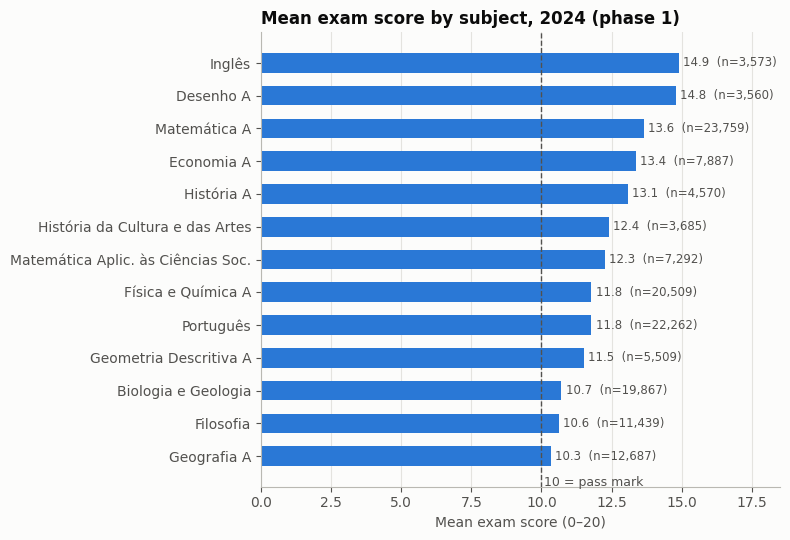

,students,mean,below_10
subject,,,
Inglês,3573,14.90,0.04
Desenho A,3560,14.78,0.02
Matemática A,23759,13.65,0.21
Economia A,7887,13.37,0.16
História A,4570,13.07,0.15
História da Cultura e das Artes,3685,12.39,0.20
Matemática Aplic. às Ciências Soc.,7292,12.27,0.18
Física e Química A,20509,11.78,0.28
Português,22262,11.78,0.22


In [4]:
by_subject = (pop.groupby("subject")
              .agg(students=("exam_score_20", "size"), mean=("exam_score_20", "mean"),
                   below_10=("exam_score", lambda s: (s < 95).mean()))
              .query("students >= 2000").sort_values("mean"))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(by_subject.index, by_subject["mean"], color=style.BLUE, height=0.6)
ax.axvline(10, color=style.TEXT_2, lw=1, ls="--")
ax.text(10.1, -0.9, "10 = pass mark", color=style.TEXT_2, fontsize=9)
for i, (m, n) in enumerate(zip(by_subject["mean"], by_subject["students"])):
    ax.text(m + 0.15, i, f"{m:.1f}  (n={n:,})", va="center", fontsize=8.5, color=style.TEXT_2)
ax.set(xlim=(0, 18.5), xlabel="Mean exam score (0–20)", title="Mean exam score by subject, 2024 (phase 1)")
ax.grid(axis="y", visible=False)
save_fig("01_mean_by_subject")
plt.show()

by_subject.sort_values("mean", ascending=False).round(2)

Averages vary a lot between subjects. Each exam has its own difficulty, and each attracts a different group of students.
To compare schools fairly in notebook 02, we will **standardise scores within each subject** (z-scores), so that a school isn't rewarded just for having more students in "easier" exams.

## 4. Gender gaps

In 2005/06 girls did better in Portuguese and boys in Maths. Does that hold for the 2024 exams?

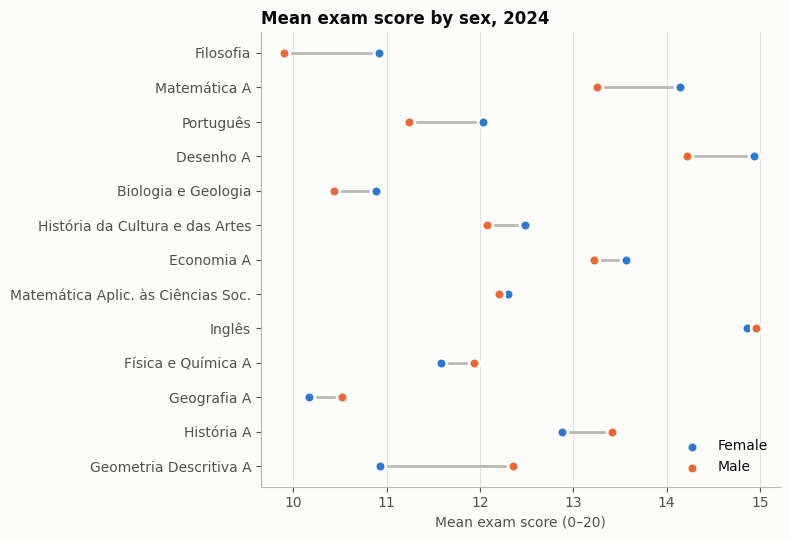

,mean_F,mean_M,gap_F_minus_M,share_female
subject,,,,
Geometria Descritiva A,10.93,12.35,-1.42,0.59
História A,12.88,13.41,-0.54,0.64
Geografia A,10.17,10.52,-0.35,0.53
Física e Química A,11.58,11.94,-0.35,0.44
Inglês,14.86,14.96,-0.10,0.64
Matemática Aplic. às Ciências Soc.,12.30,12.20,0.10,0.70
Economia A,13.57,13.22,0.34,0.41
História da Cultura e das Artes,12.48,12.07,0.41,0.79
Biologia e Geologia,10.88,10.44,0.45,0.61


In [5]:
g = (pop.groupby(["subject", "sex"])["exam_score_20"].agg(["mean", "size"]).unstack())
g.columns = [f"{a}_{b}" for a, b in g.columns]
g = g[(g["size_F"] + g["size_M"]) >= 3000].copy()
g["gap_F_minus_M"] = g["mean_F"] - g["mean_M"]
g["share_female"] = g["size_F"] / (g["size_F"] + g["size_M"])
g = g.sort_values("gap_F_minus_M")

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(g))
ax.hlines(y, g["mean_M"], g["mean_F"], color=style.NEUTRAL, lw=2)
ax.scatter(g["mean_F"], y, color=style.SEX_COLORS["F"], s=60, zorder=3, label="Female", edgecolor=style.SURFACE, lw=2)
ax.scatter(g["mean_M"], y, color=style.SEX_COLORS["M"], s=60, zorder=3, label="Male", edgecolor=style.SURFACE, lw=2)
ax.set_yticks(y, g.index)
ax.set(xlabel="Mean exam score (0–20)", title="Mean exam score by sex, 2024")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
save_fig("02_gender_gap_by_subject")
plt.show()

g[["mean_F", "mean_M", "gap_F_minus_M", "share_female"]].round(2)

**Reading the result**
- **Portuguese:** girls score higher (≈ +0.8 points), as in 2005/06.
- **Maths A:** girls *also* score higher (≈ +0.9). The 2005/06 pattern (boys ahead in Maths) **does not appear** in 2024 exam takers.
- Boys are ahead in a few subjects, most clearly **Descriptive Geometry**.

**But look at the participation column (`share_female`).** Girls are the majority of exam takers in most subjects. Maths A (44% female), Physics and Chemistry A (44%) and Economics A (41%) are the exceptions.
When more boys take an exam, the male group may include more marginal candidates, which lowers its average. So part of the Maths A gap could be about **who chooses to sit the exam** rather than ability.
Selection can't be the whole story, though: Physics and Chemistry has the same male majority, and there boys score *higher*.
Settling this would need data on all students, not only exam takers. That's a good example of a question this data *cannot* answer.

## 5. Age, a proxy for past retention

ENES has no "past failures" column, but it has **age**. Most students finish secondary school at 17. A student who is 18 or older when sitting a 12th-grade exam has usually **repeated a year at some point**.

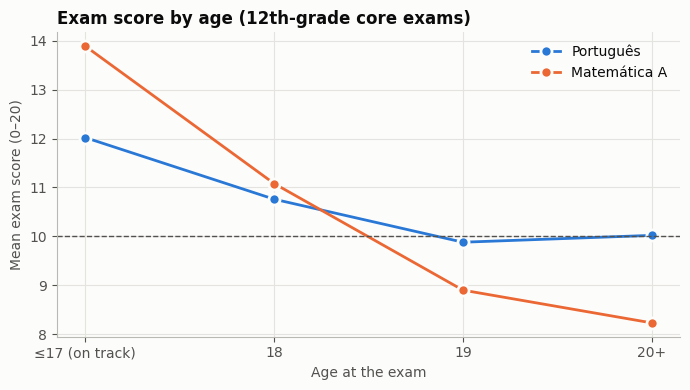

mean   size
subject      age_group                   
Matemática A ≤17 (on track)  13.89  21862
             18              11.08   1679
             19               8.90    182
             20+              8.23     36
Português    ≤17 (on track)  12.02  18428
             18              10.76   3230
             19               9.88    539
             20+             10.02     65

In [6]:
pop["age_group"] = pd.cut(pop["age"], [0, 17, 18, 19, 120], labels=["≤17 (on track)", "18", "19", "20+"])
core = pop[pop["subject"].isin(["Português", "Matemática A"])]
age_tab = core.groupby(["subject", "age_group"], observed=True)["exam_score_20"].agg(["mean", "size"]).round(2)

fig, ax = plt.subplots(figsize=(7, 4))
for subj, color in [("Português", style.BLUE), ("Matemática A", style.ORANGE)]:
    t = age_tab.loc[subj]
    t = t[t["size"] >= 30]
    ax.plot(t.index.astype(str), t["mean"], marker="o", ms=8, color=color, label=subj,
            markeredgecolor=style.SURFACE, markeredgewidth=2)
ax.axhline(10, color=style.TEXT_2, lw=1, ls="--")
ax.set(ylabel="Mean exam score (0–20)", xlabel="Age at the exam", title="Exam score by age (12th-grade core exams)")
ax.legend()
save_fig("03_score_by_age")
plt.show()
age_tab

The pattern from 2005/06 holds strongly. Students who are **behind their age group** score much lower:
- in Maths A, from ~13.9 (on track) down to ~8.9 at age 19;
- in Portuguese, from ~12.0 down to ~9.9.

Retention is a powerful marker of accumulated difficulty. It was the strongest predictor in 2005/06 and remains one of the clearest signals in 2024.
(These are associations. Repeating a year does not necessarily *cause* lower scores; it reflects difficulties that started earlier.)

## 6. Internal grades vs exam scores

Each student has an **internal grade** given by their school (0–20) and an **exam score** set nationally. The gap between them is a common, if imperfect, indicator of how generous a school's internal grading is.

In [7]:
pop["gap"] = pop["internal_grade"] - pop["exam_score_20"]
gap = (pop[pop["subject"].isin(["Português", "Matemática A"])]
       .groupby(["subject", "sector"])
       .agg(students=("gap", "size"), internal=("internal_grade", "mean"),
            exam=("exam_score_20", "mean"), gap=("gap", "mean"))
       .round(2))
print(f"Average gap, all subjects: {pop['gap'].mean():.2f} points (internal above exam)")
gap

Average gap, all subjects: 2.80 points (internal above exam)


students  internal   exam   gap
subject      sector                                  
Matemática A Private      4154     16.29  15.44  0.85
             Public      19605     15.31  13.26  2.04
Português    Private      2180     14.80  12.68  2.12
             Public      20082     14.05  11.68  2.37

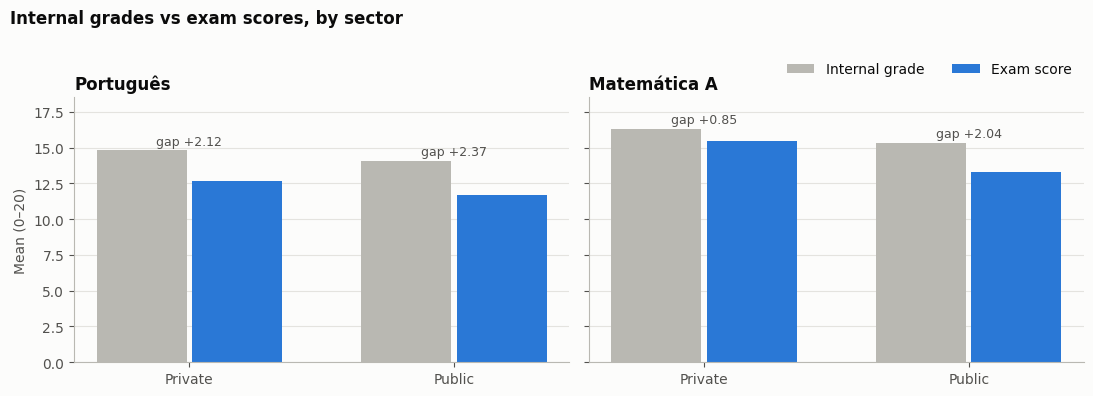

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, subj in zip(axes, ["Português", "Matemática A"]):
    t = gap.loc[subj]
    x = np.arange(len(t))
    ax.bar(x - 0.18, t["internal"], width=0.34, color=style.NEUTRAL, label="Internal grade")
    ax.bar(x + 0.18, t["exam"], width=0.34, color=style.BLUE, label="Exam score")
    for i, (a, b, d) in enumerate(zip(t["internal"], t["exam"], t["gap"])):
        ax.text(i, max(a, b) + 0.4, f"gap {d:+.2f}", ha="center", fontsize=9, color=style.TEXT_2)
    ax.set_xticks(x, t.index)
    ax.set(title=subj, ylim=(0, 18.5))
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Mean (0–20)")
axes[1].legend(loc="upper right", bbox_to_anchor=(1, 1.18), ncol=2)
fig.suptitle("Internal grades vs exam scores, by sector", x=0.01, ha="left", fontweight="bold")
save_fig("04_internal_vs_exam")
plt.show()

- On average, internal grades are **2–3 points higher** than exam scores. Part of this is expected: internal grades also reward continuous work, and the exam is a single high-stakes day.
- In **Maths A**, private schools show a much smaller gap (0.85 vs 2.04 points). Their students score much higher on the exam, while their internal grades are only slightly higher.
- This contradicts the popular idea that private schools simply "inflate" grades, at least on average and for the students who sit the exam. Large differences between *individual* schools are explored in notebook 02.

## 7. Then and now

How do the 2005/06 findings compare with the 2024 national data?

> 2005/06 values come from the student-performance project. To make them closer to 2024 exam takers, they **exclude students with a final grade of 0** (likely dropouts).

In [9]:
def mean_by(df, col, value):
    return df.loc[df[col] == value, "exam_score_20"].mean()

pt, ma = (pop[pop["subject"] == s] for s in ["Português", "Matemática A"])
gp, ms = "705810", "1214002"  # DGEEC codes for Gabriel Pereira and Mouzinho da Silveira

then_now = pd.DataFrame([
    ["Portuguese: girls minus boys", 12.48 - 11.76, mean_by(pt, "sex", "F") - mean_by(pt, "sex", "M")],
    ["Maths: girls minus boys", 11.21 - 11.87, mean_by(ma, "sex", "F") - mean_by(ma, "sex", "M")],
    ["Portuguese: on track minus behind (failures / age ≥ 18)", 12.65 - 9.44,
     pt.loc[pt["age"] <= 17, "exam_score_20"].mean() - pt.loc[pt["age"] >= 18, "exam_score_20"].mean()],
    ["Maths: on track minus behind (failures / age ≥ 18)", 11.94 - 9.57,
     ma.loc[ma["age"] <= 17, "exam_score_20"].mean() - ma.loc[ma["age"] >= 18, "exam_score_20"].mean()],
    ["Portuguese: Gabriel Pereira minus Mouzinho da Silveira", 12.61 - 11.35,
     mean_by(pt, "school_dgeec", gp) - mean_by(pt, "school_dgeec", ms)],
    ["Maths: Gabriel Pereira minus Mouzinho da Silveira", 11.62 - 10.79,
     mean_by(ma, "school_dgeec", gp) - mean_by(ma, "school_dgeec", ms)],
], columns=["Difference (points, 0–20)", "2005/06 (UCI, two schools)", "2024 (national exams)"]).set_index("Difference (points, 0–20)")
then_now.round(2)

,"2005/06 (UCI, two schools)",2024 (national exams)
"Difference (points, 0–20)",,
Portuguese: girls minus boys,0.72,0.80
Maths: girls minus boys,-0.66,0.89
Portuguese: on track minus behind (failures / age ≥ 18),3.21,1.40
Maths: on track minus behind (failures / age ≥ 18),2.37,3.07
Portuguese: Gabriel Pereira minus Mouzinho da Silveira,1.26,0.14
Maths: Gabriel Pereira minus Mouzinho da Silveira,0.83,2.00


**What held up**
- **Students who fell behind do worse.** It was true in 2005/06 (past failures) and it is true in 2024 (over-age students). The gaps are 1.4 to 3.1 points, and reach 5 points for 19-year-olds in Maths A.
- **Girls do better in Portuguese.** The size of the gap is similar.
- **Gabriel Pereira is still ahead of Mouzinho da Silveira on exam scores.** In Maths the gap has grown (≈ 2 points), while in Portuguese it has almost disappeared (≈ 0.1).

**What changed**
- **Boys are no longer ahead in Maths.** In 2024, girls who sit Maths A outscore boys. Because the 2024 data only covers university applicants, and boys are the majority in Maths A, this may reflect selection rather than a real reversal.

**Limits of the comparison**
- 2005/06 grades are internal grades for whole classes in two schools. 2024 scores are national exam results for applicants only.
- The measures differ, so we compare **directions and rough sizes** of gaps, not exact values.

**Next:** notebook 02 moves from students to **schools**. How much of a school's exam result is explained by its students' socio-economic background? And which schools do better than expected?